# Stock Return Prediction using Triple-Barrier Labeling

## 0. Imports

In [1]:
import os
import numpy as np
from typing import Optional, Tuple, List, Dict
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

## 1. Label Construction

### Configuration

In [2]:
# --------------------------------------------------
# Config
# --------------------------------------------------
DATA_DIR = "./data"
PANEL_FILE = os.path.join(DATA_DIR, "vn30_panel_daily.csv")
PROCESSED_OUT = os.path.join(DATA_DIR, "processed_vn30_panel_daily.csv")

START = "2018-01-01"
END   = "2026-03-15"

VOL_LOOKBACK = 20          # rolling vol window

### Load raw panel data

In [3]:
# --------------------------------------------------
# Load panel
# --------------------------------------------------
df = pd.read_csv(PANEL_FILE, parse_dates=["date"])

# --------------------------------------------------
# Basic cleaning
# --------------------------------------------------
print("Before cleaning:", len(df))

# remove duplicates
df = df.drop_duplicates(subset=["symbol", "date"]).copy()

# remove impossible rows
df = df[
    (df["close"] > 0) &
    (df["open"] > 0) &
    (df["high"] > 0) &
    (df["low"] > 0) &
    (df["volume"] >= 0)
].copy()

df = df.sort_values(["symbol", "date"]).reset_index(drop=True)

print("After cleaning:", len(df))

Before cleaning: 61490
After cleaning: 61489


### Compute Returns & Volatility

In [4]:
# --------------------------------------------------
# Returns and rolling volatility
# --------------------------------------------------
def add_returns_and_volatility(data: pd.DataFrame, vol_lookback: int = 20) -> pd.DataFrame:
    out = data.copy()

    # log return
    out["log_ret"] = (
        out.groupby("symbol")["close"]
        .transform(lambda s: np.log(s).diff())
    )

    # rolling realized volatility of daily log returns
    out["daily_vol"] = (
        out.groupby("symbol")["log_ret"]
        .transform(lambda s: s.rolling(vol_lookback, min_periods=vol_lookback).std())
    )

    return out

df = add_returns_and_volatility(df, vol_lookback=VOL_LOOKBACK)
print(df.head(5))

        date symbol  open  high   low  close   volume   log_ret  daily_vol
0 2018-07-02    ACB  6.87  6.87  6.33   6.43  6858520       NaN        NaN
1 2018-07-03    ACB  6.45  6.56  5.91   5.98  7375018 -0.072554        NaN
2 2018-07-04    ACB  5.89  6.18  5.89   6.18  4127586  0.032898        NaN
3 2018-07-05    ACB  6.04  6.18  5.69   5.77  4948503 -0.068646        NaN
4 2018-07-06    ACB  5.60  6.33  5.60   6.33  7854475  0.092628        NaN


### Triple-Barrier Labeling

In [5]:
def triple_barrier_for_symbol(
    g,
    pt_mult=2.0,
    sl_mult=2.0,
    horizon=10,
    ambiguous_policy="drop",   # "drop" | "open_based"
    vb_policy="zero",          # "zero" | "sign"
    neutral_width=0.25,        # in units of daily_vol
):
    n = len(g)

    labels = np.full(n, np.nan)
    hit_dates = [pd.NaT] * n
    hit_types = [None] * n
    vertical_dates = [pd.NaT] * n
    upper_barriers = np.full(n, np.nan)
    lower_barriers = np.full(n, np.nan)
    event_returns = np.full(n, np.nan)

    close_arr = g["close"].to_numpy()
    open_arr  = g["open"].to_numpy()
    high_arr  = g["high"].to_numpy()
    low_arr   = g["low"].to_numpy()
    vol_arr   = g["daily_vol"].to_numpy()
    date_arr  = g["date"].to_numpy()

    for i in range(n):
        vol = vol_arr[i]
        if np.isnan(vol):
            continue

        j_end = min(i + horizon, n - 1)
        if j_end <= i:
            continue

        entry = close_arr[i]
        upper = entry * np.exp(pt_mult * vol)
        lower = entry * np.exp(-sl_mult * vol)

        upper_barriers[i] = upper
        lower_barriers[i] = lower
        vertical_dates[i] = pd.Timestamp(date_arr[j_end])

        label = np.nan
        hit_idx = j_end
        hit_type = "vb"

        for j in range(i + 1, j_end + 1):
            up_hit = high_arr[j] >= upper
            dn_hit = low_arr[j] <= lower

            if up_hit and dn_hit:
                if ambiguous_policy == "drop":
                    label = np.nan
                    hit_idx = j
                    hit_type = "ambiguous"
                else:
                    # imperfect but deterministic fallback
                    d_up = abs(np.log(upper / open_arr[j]))
                    d_dn = abs(np.log(open_arr[j] / lower))
                    label = 1 if d_up < d_dn else -1
                    hit_idx = j
                    hit_type = "ambiguous_open_based"
                break

            elif up_hit:
                label = 1
                hit_idx = j
                hit_type = "pt"
                break

            elif dn_hit:
                label = -1
                hit_idx = j
                hit_type = "sl"
                break

        ret = np.log(close_arr[hit_idx] / entry)
        event_returns[i] = ret
        hit_dates[i] = pd.Timestamp(date_arr[hit_idx])
        hit_types[i] = hit_type

        if hit_type == "vb":
            if vb_policy == "zero":
                label = 0
            else:
                # make 0 a true "no move" zone, not a catch-all bucket
                if abs(ret) <= neutral_width * vol:
                    label = 0
                else:
                    label = 1 if ret > 0 else -1

        labels[i] = label

    out = g.copy()
    out["tb_label"] = labels
    out["tb_hit_date"] = hit_dates
    out["tb_hit_type"] = hit_types
    out["tb_vertical_date"] = vertical_dates
    out["tb_upper_barrier"] = upper_barriers
    out["tb_lower_barrier"] = lower_barriers
    out["tb_event_log_return"] = event_returns
    return out

In [6]:
# --------------------------------------------------
# Apply to all symbols
# --------------------------------------------------
labeled_list = []

# Triple-barrier parameters
VERTICAL_HORIZON = 10      # number of trading days forward
PT_MULT = 2.5              # profit-taking barrier = + PT_MULT * vol
SL_MULT = 2.5              # stop-loss barrier     = - SL_MULT * vol

for symbol, g in df.groupby("symbol", sort=True):
    labeled_g = triple_barrier_for_symbol(
        g,
        pt_mult=PT_MULT,
        sl_mult=SL_MULT,
        horizon=VERTICAL_HORIZON
    )
    labeled_list.append(labeled_g)

labeled = pd.concat(labeled_list, axis=0, ignore_index=True)
labeled = labeled.sort_values(["symbol", "date"]).reset_index(drop=True)

print(labeled["tb_label"].value_counts(dropna=False))

tb_label
 1.0    24637
-1.0    21553
 0.0    14549
 NaN      750
Name: count, dtype: int64


## 2. Feature Engineering

### Feature Construction

In [7]:
def make_features(
    df: pd.DataFrame,
    return_lags = (1, 3, 5, 10, 20),
    regime_windows = (10, 20),
    trend_window: int = 20,
    short_window: int = 5,
    long_window: int = 20,
    rsi_period: int = 14,
    include_calendar: bool = True,
    eps: float = 1e-12,
) -> pd.DataFrame:
    """
    Compact, scale-invariant feature builder.

    - standardized multi-horizon returns
    - normalized volatility regime
    - normalized volume surprise
    - one normalized distance-to-MA feature
    - one MA spread feature
    - one oscillator (RSI)
    - two normalized range/gap features
    - optional calendar features

    The explicit model feature list is stored in:
        out.attrs["feature_cols"]
    """

    required_cols = [
        "date", "symbol", "open", "high", "low", "close", "volume",
        "log_ret", "daily_vol"
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    if long_window < short_window:
        raise ValueError("long_window must be >= short_window")

    out = df.copy()
    out["date"] = pd.to_datetime(out["date"])
    out = out.sort_values(["symbol", "date"]).reset_index(drop=True)
    g = out.groupby("symbol", group_keys=False)

    feature_cols = []
    helper_cols = []

    out["log_volume"] = np.log1p(out["volume"])
    helper_cols.append("log_volume")

    daily_vol_safe = out["daily_vol"].replace(0, np.nan)

    def _rolling_zscore(s: pd.Series, win: int) -> pd.Series:
        mu = s.rolling(win, min_periods=win).mean()
        sd = s.rolling(win, min_periods=win).std()
        return (s - mu) / (sd + eps)

    def _rsi(series: pd.Series, period: int = 14) -> pd.Series:
        delta = series.diff()
        gain = delta.clip(lower=0)
        loss = -delta.clip(upper=0)
        avg_gain = gain.rolling(period, min_periods=period).mean()
        avg_loss = loss.rolling(period, min_periods=period).mean()
        rs = avg_gain / avg_loss.replace(0, np.nan)
        return 100 - (100 / (1 + rs))

    # 1) Standardized multi-horizon returns
    for lag in sorted(set(return_lags)):
        temp_col = f"_log_ret_{lag}"
        ref_win = max(max(regime_windows), lag)

        out[temp_col] = g["close"].transform(
            lambda s, lag=lag: np.log(s / s.shift(lag))
        )
        helper_cols.append(temp_col)

        feat = f"z_log_ret_{lag}"
        out[feat] = out.groupby("symbol")[temp_col].transform(
            lambda s, win=ref_win: _rolling_zscore(s, win)
        )
        feature_cols.append(feat)

    # 2) Volatility regime: keep normalized volatility only
    for win in sorted(set(regime_windows)):
        temp_col = f"_volatility_{win}"
        out[temp_col] = g["log_ret"].transform(
            lambda s, win=win: s.rolling(win, min_periods=win).std()
        )
        helper_cols.append(temp_col)

        feat = f"z_volatility_{win}"
        out[feat] = out.groupby("symbol")[temp_col].transform(
            lambda s, win=win: _rolling_zscore(s, win)
        )
        feature_cols.append(feat)

    # 3) Volume surprise: keep z-scored log volume only
    for win in sorted(set(regime_windows)):
        log_vol_ma = g["log_volume"].transform(
            lambda s, win=win: s.rolling(win, min_periods=win).mean()
        )
        log_vol_sd = g["log_volume"].transform(
            lambda s, win=win: s.rolling(win, min_periods=win).std()
        )

        feat = f"z_log_volume_{win}"
        out[feat] = (out["log_volume"] - log_vol_ma) / (log_vol_sd + eps)
        feature_cols.append(feat)

    # 4) Trend features: one normalized dist-to-MA + one MA spread
    dist_col = f"_dist_ma_{trend_window}_pct"
    out[dist_col] = (
        out["close"]
        - g["close"].transform(lambda s: s.rolling(trend_window, min_periods=trend_window).mean())
    ) / (
        g["close"].transform(lambda s: s.rolling(trend_window, min_periods=trend_window).mean()) + eps
    )
    helper_cols.append(dist_col)

    feat = f"z_dist_ma_{trend_window}"
    out[feat] = out.groupby("symbol")[dist_col].transform(
        lambda s, win=trend_window: _rolling_zscore(s, win)
    )
    feature_cols.append(feat)

    ma_short = g["close"].transform(
        lambda s: s.rolling(short_window, min_periods=short_window).mean()
    )
    ma_long = g["close"].transform(
        lambda s: s.rolling(long_window, min_periods=long_window).mean()
    )

    feat = f"ma_spread_{short_window}_{long_window}"
    out[feat] = (ma_short / (ma_long + eps)) - 1.0
    feature_cols.append(feat)

    # 5) One oscillator only: centered RSI
    feat = f"rsi_{rsi_period}_centered"
    out[feat] = (g["close"].transform(lambda s: _rsi(s, rsi_period)) - 50.0) / 50.0
    feature_cols.append(feat)

    # 6) Compact normalized range/gap block
    prev_close = g["close"].shift(1)

    feat = "hl_range_vol_adj"
    out[feat] = (
        (out["high"] - out["low"]) / (out["close"] + eps)
    ) / (daily_vol_safe + eps)
    feature_cols.append(feat)

    feat = "open_to_prev_close_vol_adj"
    out[feat] = (
        out["open"] / (prev_close + eps) - 1.0
    ) / (daily_vol_safe + eps)
    feature_cols.append(feat)

    # 7) Calendar
    if include_calendar:
        out["day_of_week"] = out["date"].dt.dayofweek
        out["month"] = out["date"].dt.month
        feature_cols.extend(["day_of_week", "month"])

    out = out.replace([np.inf, -np.inf], np.nan)
    out = out.drop(columns=helper_cols, errors="ignore")

    # Use this exact list for modeling so raw columns are excluded.
    out.attrs["feature_cols"] = feature_cols
    return out

In [8]:
df_feat = make_features(labeled)
print(df_feat.columns.tolist())
print("Num of cols: ", len(df_feat.columns.tolist()))
print(df_feat.head(5))

['date', 'symbol', 'open', 'high', 'low', 'close', 'volume', 'log_ret', 'daily_vol', 'tb_label', 'tb_hit_date', 'tb_hit_type', 'tb_vertical_date', 'tb_upper_barrier', 'tb_lower_barrier', 'tb_event_log_return', 'z_log_ret_1', 'z_log_ret_3', 'z_log_ret_5', 'z_log_ret_10', 'z_log_ret_20', 'z_volatility_10', 'z_volatility_20', 'z_log_volume_10', 'z_log_volume_20', 'z_dist_ma_20', 'ma_spread_5_20', 'rsi_14_centered', 'hl_range_vol_adj', 'open_to_prev_close_vol_adj', 'day_of_week', 'month']
Num of cols:  32
        date symbol  open  high   low  close   volume   log_ret  daily_vol  \
0 2018-07-02    ACB  6.87  6.87  6.33   6.43  6858520       NaN        NaN   
1 2018-07-03    ACB  6.45  6.56  5.91   5.98  7375018 -0.072554        NaN   
2 2018-07-04    ACB  5.89  6.18  5.89   6.18  4127586  0.032898        NaN   
3 2018-07-05    ACB  6.04  6.18  5.69   5.77  4948503 -0.068646        NaN   
4 2018-07-06    ACB  5.60  6.33  5.60   6.33  7854475  0.092628        NaN   

   tb_label  ... z_volat

### Feature Selection

In [9]:
exclude_cols = labeled.columns.tolist()

feature_cols = [c for c in df_feat.columns if c not in exclude_cols]
print("Final feature columns:", len(feature_cols))
print(feature_cols)

Final feature columns: 16
['z_log_ret_1', 'z_log_ret_3', 'z_log_ret_5', 'z_log_ret_10', 'z_log_ret_20', 'z_volatility_10', 'z_volatility_20', 'z_log_volume_10', 'z_log_volume_20', 'z_dist_ma_20', 'ma_spread_5_20', 'rsi_14_centered', 'hl_range_vol_adj', 'open_to_prev_close_vol_adj', 'day_of_week', 'month']


In [10]:
df_model = df_feat.dropna(subset=feature_cols + ["tb_label", "tb_hit_date"]).copy()
df_model.head()

,date,symbol,open,high,low,close,volume,log_ret,daily_vol,tb_label,...,z_volatility_20,z_log_volume_10,z_log_volume_20,z_dist_ma_20,ma_spread_5_20,rsi_14_centered,hl_range_vol_adj,open_to_prev_close_vol_adj,day_of_week,month
39,2018-08-24,ACB,7.37,7.59,7.32,7.49,7614923,0.016151,0.014127,-1.0,...,-1.166067,1.288939,1.660917,1.318672,0.030294,0.546875,2.551798,-9.603859e-12,4,8
40,2018-08-27,ACB,7.53,7.63,7.49,7.49,3180882,0.000000,0.013950,-1.0,...,-1.148843,-0.877111,-0.931470,1.148517,0.038046,0.524590,1.339942,3.828406e-01,0,8
41,2018-08-28,ACB,7.51,7.57,7.49,7.51,5158953,0.002667,0.013653,-1.0,...,-1.143024,0.374160,0.467528,1.006274,0.039005,0.425743,0.780218,1.955754e-01,1,8
42,2018-08-29,ACB,7.59,7.63,7.49,7.59,4615659,0.010596,0.013374,-1.0,...,-1.197420,0.135910,0.094878,1.226342,0.041725,0.457944,1.379175,7.964954e-01,2,8
43,2018-08-30,ACB,7.61,7.66,7.57,7.66,4212097,0.009180,0.013346,-1.0,...,-1.203823,-0.000517,-0.167827,1.297981,0.043911,0.442308,0.880340,1.974353e-01,3,8


In [11]:
# --------------------------------------------------
# Save labeled dataset
# --------------------------------------------------
df_model.to_csv(PROCESSED_OUT, index=False)
print("Saved:", PROCESSED_OUT)

Saved: ./data/processed_vn30_panel_daily.csv


### Data Explotary

In [12]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

def plot_tsne(
    df,
    feature_cols,
    label_col="tb_label",
    target_col="tb_event_log_return",
    sample_size=3000,
    perplexity=30,
    random_state=42,
):
    """
    Visualize whether features separate labels using t-SNE.
    """

    # ----------------------------
    # 1. Filter event rows (CRITICAL)
    # ----------------------------
    if target_col in df.columns:
        data = df[df[target_col].notna()].copy()
    else:
        data = df.copy()

    data = data.dropna(subset=feature_cols + [label_col])

    if len(data) == 0:
        raise ValueError("No valid data after filtering")

    # ----------------------------
    # 2. Subsample (t-SNE is slow)
    # ----------------------------
    if len(data) > sample_size:
        data = data.sample(sample_size, random_state=random_state)

    X = data[feature_cols].values
    y = data[label_col].values

    # ----------------------------
    # 3. Normalize (important for t-SNE)
    # ----------------------------
    X_scaled = StandardScaler().fit_transform(X)

    # ----------------------------
    # 4. Run t-SNE
    # ----------------------------
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=random_state,
        init="pca"
    )
    X_emb = tsne.fit_transform(X_scaled)

    # ----------------------------
    # 5. Plot (colored by label)
    # ----------------------------
    plt.figure(figsize=(7,6))

    unique_labels = np.unique(y)

    for label in unique_labels:
        mask = (y == label)
        plt.scatter(
            X_emb[mask, 0],
            X_emb[mask, 1],
            label=f"label={label}",
            alpha=0.6
        )

    plt.title("t-SNE: Feature space colored by label")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return X_emb

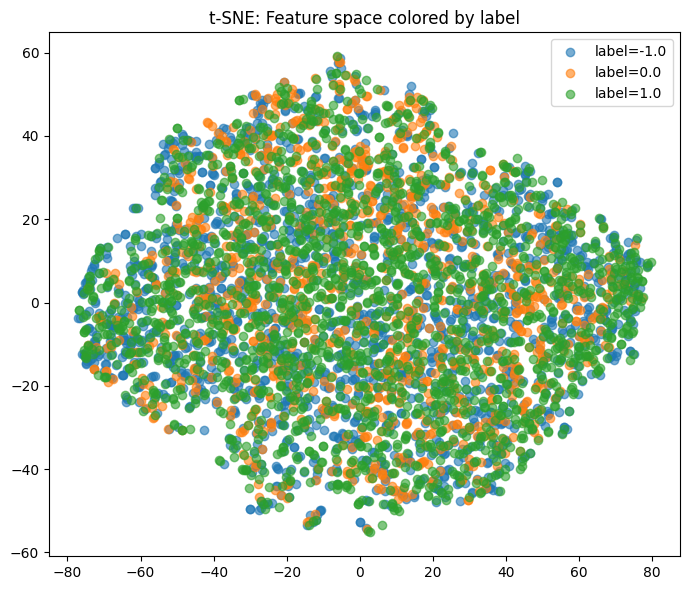

array([[-25.022276 ,  -3.8452656],
       [-39.467087 ,  19.03116  ],
       [ -6.650109 ,  21.70506  ],
       ...,
       [ 17.70141  ,  36.93297  ],
       [  2.0534558,  19.111702 ],
       [  4.740147 , -25.603394 ]], dtype=float32)

In [13]:
plot_tsne(df_model, feature_cols, sample_size=5000)

## 3. Data Splitting

### Purged Time Series Cross-Validation

In [14]:
class PurgedTimeSeriesSplit:
    def __init__(
        self,
        n_splits=5,
        embargo_days=10,
        min_train_size=252
    ):
        self.n_splits = n_splits
        self.embargo_days = embargo_days
        self.min_train_size = min_train_size

    def split(self, df):
        df = df.sort_values("date").reset_index(drop=True).copy()
        unique_dates = np.array(sorted(df["date"].unique()))

        n_dates = len(unique_dates)
        fold_size = n_dates // (self.n_splits + 1)

        for fold in range(self.n_splits):
            val_start_idx = (fold + 1) * fold_size
            if fold == self.n_splits - 1:
                val_end_idx = n_dates - 1
            else:
                val_end_idx = (fold + 2) * fold_size - 1

            val_start_date = unique_dates[val_start_idx]
            val_end_date = unique_dates[val_end_idx]
            embargo_end_date = pd.Timestamp(val_end_date) + pd.Timedelta(days=self.embargo_days)

            val_mask = (df["date"] >= val_start_date) & (df["date"] <= val_end_date)

            train_mask = df["date"] < val_start_date

            # purge training rows whose event overlaps validation
            overlap_mask = train_mask & (df["tb_hit_date"] >= val_start_date)
            train_mask = train_mask & (~overlap_mask)

            # embargo after validation
            embargo_mask = (df["date"] > val_end_date) & (df["date"] <= embargo_end_date)
            train_mask = train_mask & (~embargo_mask)

            train_idx = np.where(train_mask)[0]
            val_idx = np.where(val_mask)[0]

            if len(train_idx) < self.min_train_size:
                continue
            if len(val_idx) == 0:
                continue

            yield train_idx, val_idx

### Time-series Train - Validation / Test Split

In [15]:
def chronological_holdout_split(df, test_start="2025-01-01"):
    trainval = df[df["date"] < pd.to_datetime(test_start)].copy()
    test = df[df["date"] >= pd.to_datetime(test_start)].copy()
    return trainval, test

In [16]:
trainval_df, test_df = chronological_holdout_split(df_model, test_start="2025-01-01")

In [17]:
print("trainval:", trainval_df["date"].min(), "->", trainval_df["date"].max(), len(trainval_df))
print("test    :", test_df["date"].min(), "->", test_df["date"].max(), len(test_df))

trainval: 2018-08-24 00:00:00 -> 2024-12-31 00:00:00 50756
test    : 2025-01-02 00:00:00 -> 2026-03-12 00:00:00 9357


## 4. Model Training

### Hyperparameter Tuning on Train/Validation
- Tune 5 candidate versions for each ML model on the train-validation split only.
- Select the best version using validation performance, then evaluate only the selected model on the test set.

In [18]:
# --------------------------------------------------
# Random search spaces + model builder
# --------------------------------------------------
import json

random_state = 42

# how many sampled configs per family
n_trials_per_family = {
    "xgb": 12,
    "rf": 6,
    "svm": 6,
    "mlp": 6,
}

search_spaces = {
    "xgb": {
        "n_estimators": [100, 200, 300, 500, 700],
        "max_depth": [3, 4, 5, 6, 8],
        "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.1],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "min_child_weight": [1, 3, 5, 7],
        "gamma": [0.0, 0.1, 0.3, 0.5],
        "reg_alpha": [0.0, 0.01, 0.1, 1.0],
        "reg_lambda": [0.5, 1.0, 2.0, 5.0],
    },

    "rf": {
        "n_estimators": [200, 300, 500, 800],
        "max_depth": [6, 8, 10, 15, None],
        "min_samples_split": [2, 5, 10, 20],
        "min_samples_leaf": [1, 3, 5, 10],
        "max_features": ["sqrt", "log2", 0.5, 0.8],
        "class_weight": ["balanced", "balanced_subsample"],
    },

    "svm": {
        "C": [0.1, 0.3, 1.0, 3.0, 10.0],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto", 0.01, 0.1],
        "class_weight": ["balanced"],
    },

    "mlp": {
        "hidden_layer_sizes": [(128, 64), (256, 128, 64), (512, 256, 128, 64)],
        "activation": ["relu", "tanh"],
        "alpha": [1e-5, 1e-4, 1e-3, 1e-2],
        "learning_rate_init": [1e-4, 5e-4, 1e-3, 5e-3],
        "batch_size": [32, 64, 128],
    },
}

family_seed_offset = {
    "xgb": 11,
    "rf": 22,
    "svm": 33,
    "mlp": 44,
}


def sample_from_space(space, seed):
    rng = np.random.default_rng(seed)
    params = {}

    for k, values in space.items():
        idx = int(rng.integers(0, len(values)))
        params[k] = values[idx]

    return params


def get_trial_params(family_name, trial_id):
    # deterministic per family/trial so reruns are reproducible
    seed = random_state + family_seed_offset[family_name] * 10_000 + trial_id
    return sample_from_space(search_spaces[family_name], seed)


def build_model(family_name, params):
    if family_name == "xgb":
        return XGBClassifier(
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=random_state,
            n_jobs=-1,
            **params,
        )

    elif family_name == "rf":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                random_state=random_state,
                n_jobs=-1,
                **params
            ))
        ])

    elif family_name == "svm":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", SVC(**params))
        ])

    elif family_name == "mlp":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(
                early_stopping=True,
                max_iter=300,
                random_state=random_state,
                **params
            ))
        ])

    else:
        raise ValueError(f"Unknown family: {family_name}")

In [19]:
def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }

In [20]:
def encode_labels(y_train, y_other=None):
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)

    if y_other is None:
        return y_train_enc, le

    y_other_enc = le.transform(y_other)
    return y_train_enc, y_other_enc, le

In [21]:
def run_purged_cv(
    df,
    models_dict: Dict[str, object],
    feature_cols,
    n_splits=5,
    embargo_days=10,
    min_train_size=252,
):
    df = df.sort_values(["date", "symbol"]).reset_index(drop=True).copy()

    cv = PurgedTimeSeriesSplit(
        n_splits=n_splits,
        embargo_days=embargo_days,
        min_train_size=min_train_size,
    )
    rows = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(df), start=1):
        train_df = df.iloc[train_idx].copy()
        val_df = df.iloc[val_idx].copy()

        X_train = train_df[feature_cols]
        y_train = train_df["tb_label"]

        X_val = val_df[feature_cols]
        y_val = val_df["tb_label"]

        print(f"Fold {fold}: train={len(train_df):,}, val={len(val_df):,}, "
              f"train_end={train_df["date"].max().date()}, val=[{val_df["date"].min().date()} -> {val_df["date"].max().date()}]")

        for model_name, model_instance in models_dict.items():
            clf = clone(model_instance)

            if model_name == "xgb":
                y_train_enc, y_val_enc, le = encode_labels(y_train, y_val)
                clf.fit(X_train, y_train_enc)
                pred_enc = clf.predict(X_val)
                y_pred = le.inverse_transform(pred_enc.astype(int))
            else:
                clf.fit(X_train, y_train)
                y_pred = clf.predict(X_val)

            metrics = compute_metrics(y_val, y_pred)

            row = {
                "fold": fold,
                "model": model_name,
                "n_train": len(train_df),
                "n_val": len(val_df),
                **metrics
            }
            rows.append(row)

    cv_results = pd.DataFrame(rows)
    return cv_results

In [22]:
all_cv_results = []

save_path = "results/cross_val.csv"

# Ensure directory exists
os.makedirs(os.path.dirname(save_path), exist_ok=True)

# Resume if file exists
if os.path.exists(save_path):
    print("[INFO] Loading previous results...")
    all_cv_results = pd.read_csv(save_path).to_dict("records")

for family_name, n_trials in n_trials_per_family.items():
    for trial_id in range(1, n_trials + 1):

        already_done = any(
            (r["family"] == family_name and int(r["version"]) == trial_id)
            for r in all_cv_results
        )
        if already_done:
            print(f"[SKIP] {family_name} trial {trial_id}")
            continue

        params = get_trial_params(family_name, trial_id)
        candidate = build_model(family_name, params)

        print(f"\n{'='*80}")
        print(f"Validate {family_name} - trial {trial_id}")
        print(f"params = {params}")
        print(f"{'='*80}")

        one_model_dict = {family_name: candidate}

        try:
            cv_res = run_purged_cv(
                trainval_df,
                models_dict=one_model_dict,
                feature_cols=feature_cols,
                n_splits=5,
                embargo_days=10,
                min_train_size=252 * 2,
            ).copy()

            cv_res["family"] = family_name
            cv_res["version"] = trial_id # Changed 'trial' to 'version'
            cv_res["params_json"] = json.dumps(params, sort_keys=True, default=str)

            all_cv_results.extend(cv_res.to_dict("records"))

            # save after each successful trial
            pd.DataFrame(all_cv_results).to_csv(save_path, index=False)

        except Exception as e:
            print(f"[ERROR] {family_name} trial {trial_id}: {e}")
            continue

all_cv_results = pd.DataFrame(all_cv_results)
all_cv_results.to_csv(save_path, index=False)

[INFO] Loading previous results...
[SKIP] xgb trial 1
[SKIP] xgb trial 2
[SKIP] xgb trial 3
[SKIP] xgb trial 4
[SKIP] xgb trial 5
[SKIP] xgb trial 6
[SKIP] xgb trial 7
[SKIP] xgb trial 8
[SKIP] xgb trial 9
[SKIP] xgb trial 10
[SKIP] xgb trial 11
[SKIP] xgb trial 12
[SKIP] rf trial 1
[SKIP] rf trial 2
[SKIP] rf trial 3
[SKIP] rf trial 4
[SKIP] rf trial 5
[SKIP] rf trial 6

Validate svm - trial 1
params = {'C': 0.1, 'kernel': 'linear', 'gamma': 0.1, 'class_weight': 'balanced'}
Fold 1: train=8,308, val=8,452, train_end=2019-09-16, val=[2019-09-18 -> 2020-10-06]
Fold 2: train=16,740, val=8,436, train_end=2020-10-05, val=[2020-10-07 -> 2021-10-27]
Fold 3: train=25,158, val=8,462, train_end=2021-10-26, val=[2021-10-28 -> 2022-11-17]
Fold 4: train=33,728, val=8,477, train_end=2022-11-16, val=[2022-11-18 -> 2023-12-08]
Fold 5: train=42,039, val=8,473, train_end=2023-12-07, val=[2023-12-11 -> 2024-12-31]

Validate svm - trial 2
params = {'C': 1.0, 'kernel': 'rbf', 'gamma': 0.01, 'class_weight':

In [23]:
all_cv_results

,fold,model,n_train,n_val,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,family,version,params_json
0,1,xgb,8308,8452,0.337080,0.322154,0.325948,0.334368,0.347879,0.322154,xgb,1,"{""colsample_bytree"": 0.8, ""gamma"": 0.1, ""learn..."
1,2,xgb,16740,8436,0.392248,0.390137,0.387592,0.393282,0.405359,0.390137,xgb,1,"{""colsample_bytree"": 0.8, ""gamma"": 0.1, ""learn..."
2,3,xgb,25158,8462,0.380288,0.374635,0.369882,0.375670,0.394673,0.374635,xgb,1,"{""colsample_bytree"": 0.8, ""gamma"": 0.1, ""learn..."
3,4,xgb,33728,8477,0.371712,0.347746,0.340028,0.357454,0.374802,0.347746,xgb,1,"{""colsample_bytree"": 0.8, ""gamma"": 0.1, ""learn..."
4,5,xgb,42039,8473,0.422401,0.383788,0.378026,0.398784,0.430992,0.383788,xgb,1,"{""colsample_bytree"": 0.8, ""gamma"": 0.1, ""learn..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,1,mlp,8308,8452,0.351988,0.345311,0.345768,0.352372,0.348204,0.345311,mlp,6,"{""activation"": ""tanh"", ""alpha"": 1e-05, ""batch_..."
146,2,mlp,16740,8436,0.375652,0.371929,0.370789,0.379131,0.375853,0.371929,mlp,6,"{""activation"": ""tanh"", ""alpha"": 1e-05, ""batch_..."
147,3,mlp,25158,8462,0.396597,0.382549,0.378510,0.394618,0.388685,0.382549,mlp,6,"{""activation"": ""tanh"", ""alpha"": 1e-05, ""batch_..."
148,4,mlp,33728,8477,0.349534,0.329841,0.324266,0.339382,0.346090,0.329841,mlp,6,"{""activation"": ""tanh"", ""alpha"": 1e-05, ""batch_..."


In [24]:
from google.colab import files

files.download(save_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
# --------------------------------------------------
# Average CV metrics for each family/version
# --------------------------------------------------
tuning_summary = (
    all_cv_results
    .groupby(["family", "version"], as_index=False)[
        ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1",
         "macro_precision", "macro_recall"]
    ]
    .mean()
    .sort_values(["family", "macro_f1"], ascending=[True, False])
)

tuning_summary

,family,version,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,mlp,1,0.388452,0.372813,0.372147,0.384321,0.388596,0.372813
1,mlp,2,0.385107,0.371321,0.368292,0.379518,0.388447,0.371321
2,mlp,3,0.381341,0.366321,0.362682,0.375943,0.380505,0.366321
3,mlp,4,0.377751,0.362491,0.359084,0.371510,0.377897,0.362491
4,mlp,5,0.376260,0.360251,0.356876,0.370677,0.371787,0.360251
5,mlp,6,0.376260,0.360251,0.356876,0.370677,0.371787,0.360251
6,rf,1,0.379160,0.382262,0.376200,0.379132,0.375931,0.382262
10,rf,5,0.378633,0.389038,0.375723,0.376119,0.375220,0.389038
8,rf,3,0.379891,0.374545,0.372257,0.378611,0.377602,0.374545
11,rf,6,0.379441,0.368580,0.366320,0.375591,0.378406,0.368580


In [26]:
# --------------------------------------------------
# Best version for each model family
# --------------------------------------------------
best_versions = (
    tuning_summary
    .sort_values(["balanced_accuracy", "macro_f1", "family"], ascending=[False, False, True])
    .groupby("family", as_index=False)
    .first()
)

best_versions

,family,version,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,mlp,1,0.388452,0.372813,0.372147,0.384321,0.388596,0.372813
1,rf,5,0.378633,0.389038,0.375723,0.376119,0.375220,0.389038
2,svm,6,0.389832,0.401144,0.387392,0.388200,0.386794,0.401144
3,xgb,6,0.382702,0.367064,0.364419,0.375335,0.390245,0.367064


In [27]:
# --------------------------------------------------
# Baseline models
# --------------------------------------------------
class ModeBaseline:
    def fit(self, X, y):
        y = pd.Series(y)
        self.mode_label_ = y.mode().iloc[0]
        return self

    def predict(self, X):
        return np.repeat(self.mode_label_, len(X))


class RandomBaseline:
    def __init__(self, random_state=42):
        self.random_state = random_state

    def fit(self, X, y):
        y = pd.Series(y)
        probs = y.value_counts(normalize=True).sort_index()
        self.labels_ = probs.index.to_numpy()
        self.probs_ = probs.values
        self.rng_ = np.random.default_rng(self.random_state)
        return self

    def predict(self, X):
        return self.rng_.choice(self.labels_, size=len(X), p=self.probs_)


class PrevLabelBaseline:
    """
    Previous observed label by symbol:
    - first test row of a symbol uses the last trainval label for that symbol
    - next test rows use previous test-row prediction input logic based on chronological order
    """
    def fit(self, train_df):
        last_lbl = (
            train_df.sort_values(["symbol", "date"])
            .groupby("symbol")["tb_label"]
            .last()
        )
        self.last_train_label_by_symbol_ = last_lbl.to_dict()
        self.global_mode_ = train_df["tb_label"].mode().iloc[0]
        return self

    def predict_from_df(self, df):
        df = df.sort_values(["symbol", "date"]).copy()
        preds = []

        for symbol, g in df.groupby("symbol", sort=False):
            prev = self.last_train_label_by_symbol_.get(symbol, self.global_mode_)
            for _ in range(len(g)):
                preds.append(prev)
                # naive persistence: keep using previous observed/persisted label
                prev = prev

        out = pd.Series(preds, index=df.index)
        out = out.reindex(df.index)
        return out.loc[df.index].values


## 5.Final evaluation

In [28]:
def evaluate(
    clf,
    test_df,
    feature_cols,
):
    X_test = test_df[feature_cols]
    y_test = test_df["tb_label"]

    if clf.__class__.__name__ == "XGBClassifier":
        y_train_enc, y_test_enc, le = encode_labels(y_train, y_test)
        pred_enc = clf.predict(X_test)
        y_pred = le.inverse_transform(pred_enc.astype(int))
    else:
        y_pred = clf.predict(X_test)

    metrics = compute_metrics(y_test, y_pred)

    print("\nFinal test metrics:")
    print(metrics)

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    labels_sorted = sorted(trainval_df["tb_label"].unique())
    cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)

    print("\nConfusion matrix (labels order =", labels_sorted, "):")
    print(cm)

    return {
        "model": clf,
        "metrics": metrics,
        "y_test": y_test,
        "y_pred": y_pred,
        "confusion_matrix": cm,
    }

In [29]:
X_trainval = trainval_df[feature_cols]
y_train = trainval_df["tb_label"]   # IMPORTANT: create global y_train for your evaluate(...)

In [30]:
import json

# --------------------------------------------------
# Fit best ML models on full trainval
# --------------------------------------------------

best_ml_models = {}

# Ensure all_cv_results is a DataFrame for easier querying
all_cv_results_df = pd.DataFrame(all_cv_results)

for _, row in best_versions.iterrows():
    family = row["family"]
    version = int(row["version"])

    # Retrieve the parameters for this best version
    best_params_row = all_cv_results_df[
        (all_cv_results_df["family"] == family) &
        (all_cv_results_df["version"] == version)
    ].iloc[0]

    best_params = json.loads(best_params_row["params_json"])

    # Build the model using the best parameters
    clf = build_model(family, best_params)

    print(f"Training {family} - version {version} with parameters: {best_params}...")
    if family == "xgb":
        y_train_enc, le = encode_labels(y_train)
        clf.fit(X_trainval, y_train_enc)
    else:
        clf.fit(X_trainval, y_train)

    best_ml_models[f"{family}_v{version}"] = clf

list(best_ml_models.keys())

Training mlp - version 1 with parameters: {'activation': 'tanh', 'alpha': 0.01, 'batch_size': 128, 'hidden_layer_sizes': [128, 64], 'learning_rate_init': 0.0005}...
Training rf - version 5 with parameters: {'class_weight': 'balanced', 'max_depth': 8, 'max_features': 0.5, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 300}...
Training svm - version 6 with parameters: {'C': 0.3, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}...
Training xgb - version 6 with parameters: {'colsample_bytree': 0.8, 'gamma': 0.5, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 200, 'reg_alpha': 0.01, 'reg_lambda': 2.0, 'subsample': 1.0}...


['mlp_v1', 'rf_v5', 'svm_v6', 'xgb_v6']

In [37]:
# --------------------------------------------------
# Evaluate best ML models with your existing evaluate(...)
# --------------------------------------------------
ml_test_results = []

for model_name, clf in best_ml_models.items():
    best_model_name = model_name   # IMPORTANT: create global expected by evaluate(...)
    out = evaluate(
        clf=clf,
        test_df=test_df,
        feature_cols=feature_cols,
    )

    ml_test_results.append({
        "name": model_name,
        "type": "ml",
        **out["metrics"],
    })

ml_test_results = pd.DataFrame(ml_test_results)
ml_test_results


Final test metrics:
{'accuracy': 0.42609810836806666, 'balanced_accuracy': np.float64(0.40915052049101425), 'macro_f1': 0.4143253658171682, 'weighted_f1': 0.424519127952072, 'macro_precision': 0.4260463090011039, 'macro_recall': 0.40915052049101425}

Classification report:
              precision    recall  f1-score   support

        -1.0       0.35      0.38      0.37      3015
         0.0       0.46      0.34      0.39      2247
         1.0       0.47      0.51      0.49      4095

    accuracy                           0.43      9357
   macro avg       0.43      0.41      0.41      9357
weighted avg       0.43      0.43      0.42      9357


Confusion matrix (labels order = [np.float64(-1.0), np.float64(0.0), np.float64(1.0)] ):
[[1143  369 1503]
 [ 603  766  878]
 [1478  539 2078]]

Final test metrics:
{'accuracy': 0.41391471625521, 'balanced_accuracy': np.float64(0.4253601164467395), 'macro_f1': 0.4085196662690675, 'weighted_f1': 0.41143259793953496, 'macro_precision': 0.41118

,name,type,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,mlp_v1,ml,0.426098,0.409151,0.414325,0.424519,0.426046,0.409151
1,rf_v5,ml,0.413915,0.425360,0.408520,0.411433,0.411181,0.425360
2,svm_v6,ml,0.417762,0.429279,0.415612,0.417296,0.415758,0.429279
3,xgb_v6,ml,0.465213,0.425121,0.426585,0.449184,0.457258,0.425121


In [ ]:
# --------------------------------------------------
# Evaluate baselines on test
# --------------------------------------------------

# fit baselines
mode_baseline = ModeBaseline().fit(X_trainval, y_train)
random_baseline = RandomBaseline(random_state=42).fit(X_trainval, y_train)
prev_baseline = PrevLabelBaseline().fit(trainval_df)

y_test = test_df["tb_label"]

baseline_rows = []

# Mode baseline
y_pred_mode = mode_baseline.predict(test_df[feature_cols])
baseline_rows.append({
    "name": "mode_baseline",
    "type": "baseline",
    **compute_metrics(y_test, y_pred_mode),
})

# Random baseline
y_pred_random = random_baseline.predict(test_df[feature_cols])
baseline_rows.append({
    "name": "random_baseline",
    "type": "baseline",
    **compute_metrics(y_test, y_pred_random),
})

# Previous-label baseline
y_pred_prev = prev_baseline.predict_from_df(test_df)
baseline_rows.append({
    "name": "prev_label_baseline",
    "type": "baseline",
    **compute_metrics(y_test, y_pred_prev),
})

baseline_test_results = pd.DataFrame(baseline_rows)
baseline_test_results

In [38]:
# --------------------------------------------------
# Final comparison: best ML models vs 3 baselines
# --------------------------------------------------
final_comparison = pd.concat(
    [ml_test_results, baseline_test_results],
    ignore_index=True
).sort_values(["macro_f1", "balanced_accuracy"], ascending=False)

final_comparison

,name,type,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
3,xgb_v6,ml,0.465213,0.425121,0.426585,0.449184,0.457258,0.425121
2,svm_v6,ml,0.417762,0.429279,0.415612,0.417296,0.415758,0.429279
0,mlp_v1,ml,0.426098,0.409151,0.414325,0.424519,0.426046,0.409151
1,rf_v5,ml,0.413915,0.425360,0.408520,0.411433,0.411181,0.425360
5,random_baseline,baseline,0.347120,0.332561,0.331607,0.348718,0.332407,0.332561
6,prev_label_baseline,baseline,0.322005,0.325911,0.225808,0.229937,0.295392,0.325911
4,mode_baseline,baseline,0.437640,0.333333,0.202944,0.266449,0.145880,0.333333


In [ ]:
import joblib
import os

# Define the directory to save models
MODELS_DIR = "./models"
os.makedirs(MODELS_DIR, exist_ok=True)

# Iterate through the best_ml_models and save each one
for model_name, model in best_ml_models.items():
    filename = os.path.join(MODELS_DIR, f"{model_name}.joblib")
    joblib.dump(model, filename)
    print(f"Saved model '{model_name}' to {filename}")

In [36]:
import shutil
from google.colab import files

# Define the folder to download and the name for the zip file
folder_to_zip = MODELS_DIR  # Assuming MODELS_DIR is defined from previous steps
zip_filename = "models.zip"

# Create a zip archive of the folder
shutil.make_archive(folder_to_zip, 'zip', folder_to_zip)

# Download the zip file
files.download(zip_filename)
print(f"The folder '{folder_to_zip}' has been zipped to '{zip_filename}' and is now available for download.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The folder './models' has been zipped to 'models.zip' and is now available for download.


The models have been saved to the `./models` directory.